# 样章 · 检查数值模拟

## 学习目标与先修知识

完成后，你能用解析解（analytical solution）评估数值误差（numerical error），推导欧拉法（forward Euler method）的平衡（equilibrium）偏差递推，并区分数值稳定性（numerical stability）与非负性（nonnegativity）。

**先修知识**：[从变化率进入微分方程](04-rates-ode.ipynb)中的解析解与初值（initial condition）关系。


## 具体问题

同一个连续衰减模型，为什么程序有时会算出振荡甚至负物质量？先不更改模型，只更改步长。

## 初步实验

无流入，A₀ = 10 U，k = 0.75 /T。h = 2 T 时，一步更新为 10 × (1 − 1.5) = −5 U。
清除项使用了区间起点的存量（stock），因此一次“预支”了过多清除量。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
from systems_science.theme import DATA_COLORS, SERIES_COLORS

plot_style()

In [2]:
for step in [1.0, 2.0]:
    next_amount = 10 + step * (0 - 0.75 * 10)
    print(f"h={step:g} T，一步之后 A={next_amount:g} U")

h=1 T，一步之后 A=2.5 U
h=2 T，一步之后 A=-5 U


## 模型假设

把研究对象看成一个**充分混合的单室模型（one-compartment model）**：用一个数描述室内示踪物质（tracer）总量。
示踪物质只是便于思考的标记物。本单元使用人工单位 U 与 T，参数（parameter）是教学选择，
不对应具体药物、患者或真实生理测量。边界外的输入被视为已知；不讨论组织容积、
浓度（concentration）、多室交换或观测噪声。A 是物质量，不是浓度。

| 量 | 含义 | 单位与条件 |
|---|---|---|
| $t$ | 从实验起点经过的时间 | T，$t\geq0$ |
| $A$、$A_0$ | 当前与初始物质量 | U，连续模型非负 |
| $u$ | 流入速率 | U/T，非负 |
| $k$ | 比例清除系数（elimination rate constant） | 1/T，非负 |
| $h$ | 计算时间步长（time step） | T，正数 |

假设清除速率为 $kA$，单位是 U/T。这个比例关系是一项建模假设，
不代表所有物质在任意条件下都按同一机制清除。

## 数学解释与推导

### 准确性：与连续解相差多少

定义最大绝对误差（maximum absolute error） $E_h=\max_n|A_n-A(t_n)|$。必须在每个步长自己的网格上比较同一时刻，
不能拿不同时间位置的数组直接相减。如果 $E_h\approx Ch^p$，减半步长后误差约缩小 $2^p$ 倍。
因此观察阶（observed order of convergence） $p\approx\log_2(E_h/E_{h/2})$。这里 log₂ 是“2 的几次方能得到该比值”。
光滑解、固定有限观察区间且步长足够小时，欧拉法 一般呈一阶收敛（first-order convergence）；实验用于检查这个趋势。

### 数值稳定性：偏离平衡后会不会放大

对恒定 u、k > 0，令 $e_n=A_n-A_*$。这里 e 是**相对平衡的偏差**，不是上面的数值解误差。
将 $A_n=e_n+A_*$ 代入更新式，并利用 $u=kA_*$：

$$e_{n+1}=e_n+h[u-k(e_n+A_*)]=(1-kh)e_n.$$

若 $|1-kh|<1$，偏差每步缩小，也就是 $0<kh<2$。
当 $kh=2$，偏差符号交替而大小不减；$kh>2$ 时，除恰好在平衡等特殊初值外会放大。

### 非负性：物质量会不会算成负值

更新还可写成 $A_{n+1}=(1-kh)A_n+hu$。对所有非负 Aₙ 与 u，要保证下一步非负，
需 $0\leq kh\leq1$。若 kh > 1，取 u = 0、Aₙ > 0 就能构造负值。
所以 $1<kh<2$ 时，可能“偏差收敛”却出现负物质量。
稳定并不保证精确，某次轨迹恰好非负也不表示方法对所有初值都保持非负。

这些条件只针对本节模型与显式 欧拉法。k = 0 时是线性积累，不能套用 k > 0 的平衡讨论。

## 核心实现

分别保留数值循环和解析公式。两者必须用相同模型参数，却不能要求结果逐点完全相等。

In [3]:
def euler(u=1.0, k=0.5, A0=0.0, h=0.1, duration=20.0):
    """恒定输入下的显式 Euler；保留负值以识别数值失败。"""
    if not all(np.isfinite(v) for v in (u, k, A0, h, duration)):
        raise ValueError("参数必须是有限数")
    if min(u, k, A0) < 0 or h <= 0 or duration <= 0:
        raise ValueError("输入、清除和初值非负，步长与时长为正")
    n_steps = round(duration / h)
    if n_steps < 1 or not np.isclose(n_steps * h, duration, rtol=0, atol=1e-10):
        raise ValueError("本节要求步长整除观察时长；分段步长见 S06")
    times = np.linspace(0.0, duration, n_steps + 1)
    amounts = np.empty(n_steps + 1)
    amounts[0] = A0
    for n in range(n_steps):
        dt = times[n + 1] - times[n]
        inflow = u * dt
        outflow = k * amounts[n] * dt
        amounts[n + 1] = amounts[n] + inflow - outflow
    if not np.all(np.isfinite(amounts)):
        raise FloatingPointError("数值结果非有限，请检查步长")
    return times, amounts

In [4]:
def exact_amount(t, u=1.0, k=0.5, A0=0.0):
    """恒定输入解析解，显式处理零清除与很小的 k。"""
    t = np.asarray(t, dtype=float)
    if not np.all(np.isfinite(t)) or np.any(t < 0):
        raise ValueError("时间必须有限且非负")
    if not all(np.isfinite(v) and v >= 0 for v in (u, k, A0)):
        raise ValueError("模型参数必须有限且非负")
    if k == 0:
        return A0 + u * t
    # expm1(x) 计算 exp(x)-1，避免小 x 时两个接近的数相减。
    return A0 * np.exp(-k * t) + u * (-np.expm1(-k * t) / k)

| h / T | 最大误差 / U |
| --- | --- |
| 0.5 | 0.102946 |
| 0.25 | 0.0485411 |
| 0.125 | 0.0236106 |

相邻两组观察阶： [1.0846 1.0398]


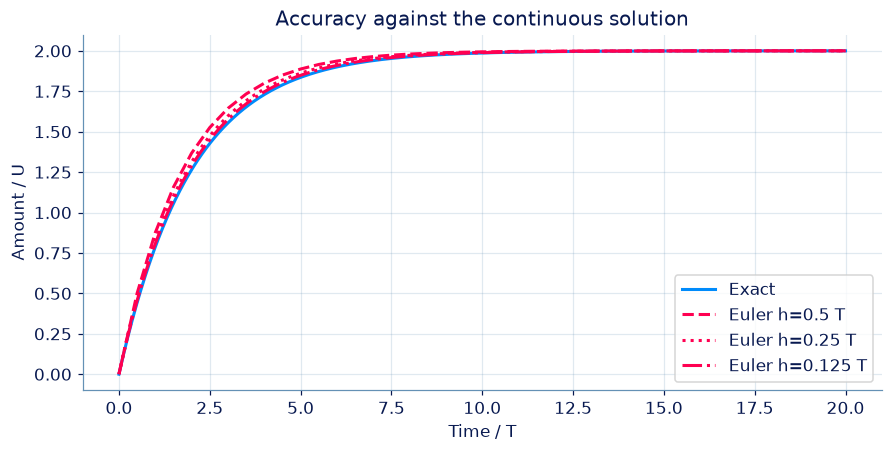

In [5]:
step_sizes = np.array([0.5, 0.25, 0.125])
errors = []
fig, ax = plt.subplots()
dense_times = np.linspace(0, 20, 1001)
ax.plot(dense_times, exact_amount(dense_times), color=SERIES_COLORS["exact"], label="Exact")
for step, style in zip(step_sizes, ["--", ":", "-."]):
    t, a = euler(h=step)
    error = np.max(np.abs(a - exact_amount(t)))
    errors.append(error)
    ax.plot(t, a, style, color=SERIES_COLORS["euler"], label=f"Euler h={step:g} T")
orders = np.log2(np.array(errors[:-1]) / np.array(errors[1:]))
assert np.all(np.diff(errors) < 0)
assert np.all((orders > 0.8) & (orders < 1.2))
display(Markdown(show_table(["h / T", "最大误差 / U"], zip(step_sizes, errors))))
print("相邻两组观察阶：", np.round(orders, 4))
ax.set(xlabel="Time / T", ylabel="Amount / U", title="Accuracy against the continuous solution")
ax.legend()
plt.show()

## 对照实验

第一组保持 u = 0、A₀ = 10、k = 0.75，只改变 h。
第二组保持 u = 0、A₀ = 10、k = 0.5，对比稳定边界与发散。
图中负值全部保留，灰色零线帮助观察物理合理性的失效。两图纵轴范围分别适配各自实验。

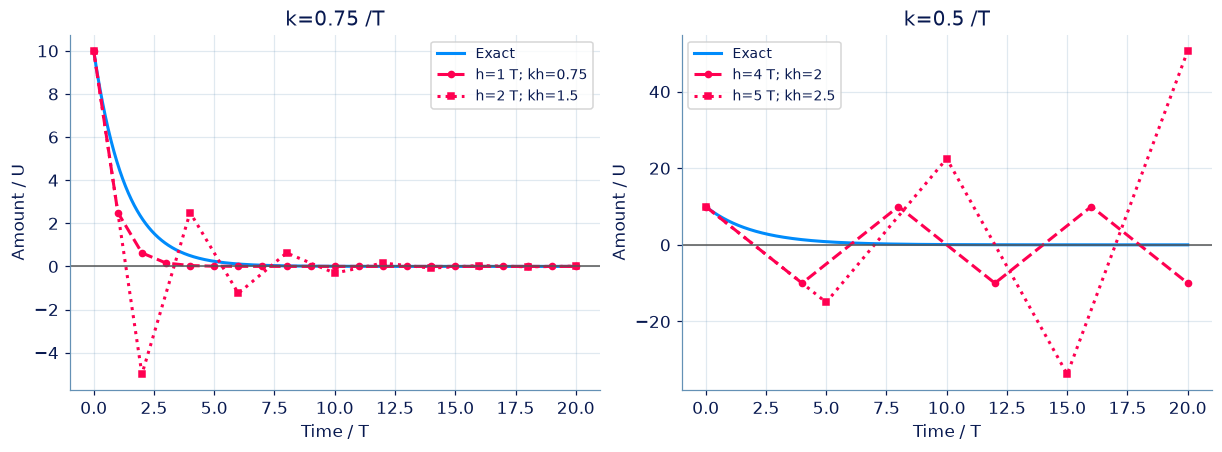

| k / (1/T) | h / T | 最小值 / U | 终点 / U |
| --- | --- | --- | --- |
| 0.75 | 1 | 9.09495e-12 | 9.09495e-12 |
| 0.75 | 2 | -5 | 0.00976562 |
| 0.5 | 4 | -10 | -10 |
| 0.5 | 5 | -33.75 | 50.625 |

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
failure_rows = []
for ax, clearance, steps in [(axes[0], 0.75, [1, 2]), (axes[1], 0.5, [4, 5])]:
    tt = np.linspace(0, 20, 1001)
    ax.plot(tt, exact_amount(tt, u=0, k=clearance, A0=10), color=SERIES_COLORS["exact"], label="Exact")
    for step, style in zip(steps, ["--o", ":s"]):
        t, a = euler(u=0, k=clearance, A0=10, h=step)
        ax.plot(t, a, style, color=SERIES_COLORS["euler"], markersize=4, label=f"h={step} T; kh={clearance*step:g}")
        failure_rows.append([clearance, step, a.min(), a[-1]])
    ax.axhline(0, color=SERIES_COLORS["reference"], linewidth=1)
    ax.set(xlabel="Time / T", ylabel="Amount / U", title=f"k={clearance:g} /T")
    ax.legend(fontsize=9)
plt.show()
display(Markdown(show_table(["k / (1/T)", "h / T", "最小值 / U", "终点 / U"], failure_rows)))
assert euler(u=0, k=0.75, A0=10, h=2)[1][1] == -5
assert np.all(euler(u=0, k=0.75, A0=10, h=1)[1] >= 0)
assert np.allclose(np.abs(euler(u=0, k=0.5, A0=10, h=4)[1]), 10)
assert abs(euler(u=0, k=0.5, A0=10, h=5)[1][-1]) > 10

## 结果解释

默认情形的最大误差约为 0.102946、0.048541、0.023611 U，观察阶约 1.085 与 1.040。
减半步长的误差检查支持一阶趋势。另一方面，kh = 1.5 时从 10 到 −5 再到 2.5，
偏差交替缩小但违背物质量非负的要求；kh = 2 时不衰减，kh = 2.5 时放大。
这些振荡由算法造成，连续模型的指数衰减没有振荡。把负值截为零会偷偷更改模型并掩盖问题。

## 练习与参考资料

先独立作答，再提交核对。每道题的题面和输入输出示例如下。

### 第 1 题 · 多项选择题：稳定、非负与准确是不同检查

显式欧拉法（forward Euler method）用于 A′=u−kA。下面哪些判断成立？选择所有正确项。

- **A.** 平滑且非负的曲线也可能有较大的数值误差（numerical error）
- **B.** k>0 时，0<kh<2 保证平衡（equilibrium）偏差递推收敛
- **C.** 1<kh<2 可以偏差收敛却产生负物质量
- **D.** 只检查数值稳定性（numerical stability）就足以证明结果准确

[作答：稳定、非负与准确是不同检查](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=accuracy-stability-positivity)

### 第 2 题 · Python 计算题：保留并识别数值负值

使用显式欧拉法（forward Euler method）对多个步长分别计算前 steps 步，报告第一次更新和整条离散轨迹的最小存量（stock），以检查非负性（nonnegativity）。

**函数与代码模板**

```python
def solve(
    u: float,
    k: float,
    A0: float,
    hs: list[float],
    steps: int,
) -> tuple[list[float], list[float]]:
    # 依次返回 first, minimum。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `u` | `float` | 每单位时间流入的物质量，整个计算期间不变。 | U/T |
| `k` | `float` | 清除系数（elimination rate constant）；物质量为 A 时，清除流率为 k·A。 | 1/T |
| `A0` | `float` | 计算开始时的物质量。 | U |
| `hs` | `list[float]` | 要独立尝试的步长；每种步长都从相同的 A0 开始。 | T |
| `steps` | `int` | 从初始时刻出发，需要执行的更新次数。 | 步 |

**返回值**

按以下顺序返回元组：(first, minimum)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `first` | `list[float]` | first[i] 是使用 hs[i] 完成第一次更新后的物质量。 | U |
| `minimum` | `list[float]` | minimum[i] 是该次实验中初始点与全部更新结果的最小值。 | U |

**计算规则**

对 hs 中的每个 h，独立从 A0 开始按 A_next=A+h·(u−k·A) 计算 steps 步。记录第一步及包含起点的全程最小值，依次返回 (first, minimum)。

**约束与边界**

- 0 ≤ u、A0 ≤ 100，0 ≤ k ≤ 1；hs 有 1 到 20 项，每项 0 < h ≤ 5。
- steps 是 1 到 100 的整数；两个返回列表与 hs 等长。
- 最小值必须包括初值（initial condition）；不得裁剪负值，也不得把上一种步长的终点用作下一种的起点。

**输入样例**

以下是一组传给 solve 的参数；U、T 分别是物质量与时间单位。每个参数直接对应上方函数签名中的同名变量。

给定条件

| 量的含义 | 函数参数 | 给定值 | 单位 |
| --- | --- | --- | --- |
| 恒定流入速率 | u | 0 | U/T |
| 清除系数 | k | 0.75 | 1/T |
| 初始物质量 | A0 | 10 | U |
| 更新步数 | steps | 5 | 步 |

分别尝试以下步长

| 实验 | 时间步长 hs / T |
| --- | --- |
| 1 | 2 |
| 2 | 1 |
| 3 | 0.5 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
u = 0
k = 0.75
A0 = 10
hs = [2, 1, 0.5]
steps = 5

result = solve(u, k, A0, hs, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

每种步长独立从同一起点计算

| 步长 / T | 第一步物质量 first / U | 全程最小物质量 minimum / U |
| --- | --- | --- |
| 2 | -5 | -5 |
| 1 | 2.5 | 0.009765625 |
| 0.5 | 6.25 | ≈ 0.9536743 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([-5.0, 2.5, 6.25],
                   [-5.0, 0.009765625, 0.95367431640625])
```

**样例解释**

u=0、k=0.75 时，每一步把 A 乘以 1−0.75h。三个步长的第一步为 −5、2.5、6.25 U；前 5 步连同起点的最小值分别为 −5、0.009765625、0.95367431640625 U。

数值核验允许绝对误差 1e-08 或相对误差 1e-07；允许使用 Python 标准库。

[作答：保留并识别数值负值](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=detect-negative-values)

### 第 3 题 · Python 计算题：找到满足误差要求的第一个步长

从 start_h 开始不断减半，用解析解（analytical solution）核对显式欧拉法（forward Euler method），返回第一个最大绝对误差（maximum absolute error）严格小于 tol 的步长。

**函数与代码模板**

```python
def solve(
    u: float,
    k: float,
    A0: float,
    end: float,
    start_h: float,
    tol: float,
) -> tuple[float, int, float]:
    # 依次返回 h, steps, error。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `u` | `float` | 每单位时间流入的物质量，整个计算期间不变。 | U/T |
| `k` | `float` | 清除系数（elimination rate constant）；物质量为 A 时，清除流率为 k·A。 | 1/T |
| `A0` | `float` | 计算开始时的物质量。 | U |
| `end` | `float` | 从 t=0 开始的观察终点。 | T |
| `start_h` | `float` | 第一次尝试的步长，之后每次除以 2。 | T |
| `tol` | `float` | 允许的误差阈值；实际最大误差必须严格小于它。 | U |

**返回值**

按以下顺序返回元组：(h, steps, error)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `h` | `float` | 首次满足误差要求的步长。 | T |
| `steps` | `int` | 该步长在 0 到 end 上的更新次数，即 round(end/h)。 | 步 |
| `error` | `float` | 该次实验所有网格点的最大绝对误差。 | U |

**计算规则**

依次尝试 start_h、start_h/2、start_h/4……。每次从 A0 重新用 A_next=A+h·(u−k·A) 模拟至 end，并在同一网格计算解析参考。若 max|数值物质量−解析物质量| < tol，立即返回 (h, steps, error)。

**约束与边界**

- 0 ≤ u、A0 ≤ 100，0 ≤ k ≤ 1；0 < end ≤ 100，0 < start_h ≤ end，tol>0。
- end/start_h 为整数；给定条件保证最多减半 12 次即可满足要求，满足要求时步数不超过 100000。
- 误差包含初始点与终点；k=0 的解析参考为 A0+u·t。必须返回首次满足严格不等式的步长。

**输入样例**

以下是一组传给 solve 的参数；U、T 分别是物质量与时间单位。每个参数直接对应上方函数签名中的同名变量。

给定条件

| 量的含义 | 函数参数 | 给定值 | 单位 |
| --- | --- | --- | --- |
| 恒定流入速率 | u | 1 | U/T |
| 清除系数 | k | 0.5 | 1/T |
| 初始物质量 | A0 | 0 | U |
| 观察终点 | end | 20 | T |
| 首次尝试的步长 | start_h | 0.5 | T |
| 允许的最大误差 | tol | 0.01 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
u = 1
k = 0.5
A0 = 0
end = 20
start_h = 0.5
tol = 0.01

result = solve(u, k, A0, end, start_h, tol)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 量的含义 | 返回量 | 结果 | 单位 |
| --- | --- | --- | --- |
| 时间步长 | h | 0.03125 | T |
| 更新步数 | steps | 640 | 步 |
| 网格上的最大误差 | error | ≈ 0.005785834 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.03125, 640, 0.005785833855069811)
```

**样例解释**

从 0.5 T 依次减半到 0.03125 T 时，首次使最大误差小于 0.01 U。此时 20/0.03125=640 步，网格上的最大误差约为 0.005785834 U。

数值核验允许绝对误差 1e-08 或相对误差 1e-07；允许使用 Python 标准库。

[作答：找到满足误差要求的第一个步长](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=choose-step-size)

### 第 4 题 · 单项选择题：缩小步长能修复错误机制吗

你使用欧拉法（forward Euler method）模拟按现有物质量比例清除的模型，却把清除项 kA 写成了常数 k。不断减小时间步长（time step）h，能够证明这个实现正确吗？

- **A.** 能够，足够小的步长会修复任何错误
- **B.** 不能，它可能只是更精确地求解了另一个模型
- **C.** 能够，只需观察曲线越来越光滑
- **D.** 能够，只要计算结果始终非负

[作答：缩小步长能修复错误机制吗](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=wrong-mechanism)

### 第 5 题 · 多项选择题：临界步长的振荡为何不消失

纯清除模型用欧拉法（forward Euler method）更新：Aₙ₊₁=(1−kh)Aₙ。令 A₀=1 U，k=0.5 /T，时间步长（time step）h=4 T。对所得序列，哪些说法正确？

- **A.** 序列交替为 1、−1、1、−1，振幅不衰减
- **B.** 数值有界就意味着它准确描述清除
- **C.** 出现负值，不能把它当作合理的物质量
- **D.** 连续模型的衰减不保证这个步长下的计算也衰减

[作答：临界步长的振荡为何不消失](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=critical-step-oscillation)

**进一步阅读**：[SciPy 积分与 ODE 文档](https://docs.scipy.org/doc/scipy/tutorial/integrate.html)：了解后续可用的数值求解器；本节使用显式 欧拉法 便于检查每一步。本节讲解、推导组织和代码为本项目编写。

[下一节：独立迁移实验](06-transfer-experiment.ipynb) · [单元目录](README.md)


[观察存量与流量](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#stock-flow) · [比较步长与数值误差](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#step-size) · [学习指南](../../../docs/学习指南.md)
